In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [2]:
import os
import random


import tensorflow as tf
from keras import backend as K
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, Reshape, Bidirectional, LSTM, Dense, Lambda, Activation, BatchNormalization, Dropout
from keras.optimizers import Adam

In [3]:
import kagglehub
path = kagglehub.dataset_download("landlord/handwriting-recognition")

100%|██████████| 1.26G/1.26G [00:11<00:00, 116MB/s]

Extracting files...


In [4]:
import matplotlib.pyplot as plt
import cv2

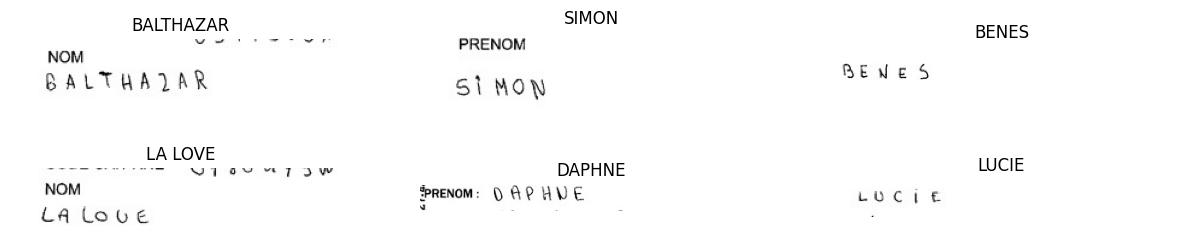

In [5]:
import os
import pandas as pd
import cv2
import matplotlib.pyplot as plt

kaggle_data_root = path

# Load the train and valid dataframes using the correct path
train = pd.read_csv(os.path.join(kaggle_data_root, 'written_name_train_v2.csv'))
valid = pd.read_csv(os.path.join(kaggle_data_root, 'written_name_validation_v2.csv'))

# Apply necessary preprocessing steps as seen in original notebook cells
train.dropna(axis=0, inplace=True)
valid.dropna(axis=0, inplace=True)
train = train[train['IDENTITY'] != 'UNREADABLE']
valid = valid[valid['IDENTITY'] != 'UNREADABLE']
train['IDENTITY'] = train['IDENTITY'].str.upper()
valid['IDENTITY'] = valid['IDENTITY'].str.upper()
train.reset_index(inplace = True, drop=True)
valid.reset_index(inplace = True, drop=True)


plt.figure(figsize=(15, 10))

for i in range(6):
    ax = plt.subplot(2, 3, i+1)
    # Correct the image directory path and column name
    img_dir_full = os.path.join(kaggle_data_root, 'train_v2', 'train', train.loc[i, 'FILENAME'])
    image = cv2.imread(img_dir_full, cv2.IMREAD_GRAYSCALE)
    plt.imshow(image, cmap = 'gray')
    plt.title(train.loc[i, 'IDENTITY'], fontsize=12)
    plt.axis('off')

plt.subplots_adjust(wspace=0.2, hspace=-0.8)

In [6]:
print("Number of NaNs in train set      : ", train['IDENTITY'].isnull().sum())
print("Number of NaNs in validation set : ", valid['IDENTITY'].isnull().sum())

Number of NaNs in train set      :  0
Number of NaNs in validation set :  0


In [7]:
train.dropna(axis=0, inplace=True)
valid.dropna(axis=0, inplace=True)

In [8]:
import os
import matplotlib.pyplot as plt

unreadable = train[train['IDENTITY'] == 'UNREADABLE']
unreadable.reset_index(inplace = True, drop=True)

plt.figure(figsize=(15, 10))

if unreadable.empty:
    print("No 'UNREADABLE' entries found in the train dataset after preprocessing.")
else:
    # Ensure we don't try to plot more than available unreadable samples
    num_to_plot = min(6, len(unreadable))
    for i in range(num_to_plot):
        ax = plt.subplot(2, 3, i+1)
        # Correct the image directory path using the 'kaggle_data_root' variable
        img_dir = os.path.join(kaggle_data_root, 'train_v2', 'train', unreadable.loc[i, 'FILENAME'])
        image = cv2.imread(img_dir, cv2.IMREAD_GRAYSCALE)
        plt.imshow(image, cmap = 'gray')
        plt.title(unreadable.loc[i, 'IDENTITY'], fontsize=12)
        plt.axis('off')

    plt.subplots_adjust(wspace=0.2, hspace=-0.8)

No 'UNREADABLE' entries found in the train dataset after preprocessing.


<Figure size 1500x1000 with 0 Axes>

In [9]:
train = train[train['IDENTITY'] != 'UNREADABLE']
valid = valid[valid['IDENTITY'] != 'UNREADABLE']

In [10]:
train['IDENTITY'] = train['IDENTITY'].str.upper()
valid['IDENTITY'] = valid['IDENTITY'].str.upper()

In [11]:
train.reset_index(inplace = True, drop=True)
valid.reset_index(inplace = True, drop=True)

In [12]:
def preprocess(img):
    (h, w) = img.shape

    final_img = np.ones([64, 256])*255 # blank white image

    # crop
    if w > 256:
        img = img[:, :256]

    if h > 64:
        img = img[:64, :]


    final_img[:h, :w] = img
    return cv2.rotate(final_img, cv2.ROTATE_90_CLOCKWISE)

In [13]:
train_size = 30000
valid_size= 3000

In [14]:
train_x = []

for i in range(train_size):
    img_dir = os.path.join(kaggle_data_root, 'train_v2', 'train', train.loc[i, 'FILENAME'])
    image = cv2.imread(img_dir, cv2.IMREAD_GRAYSCALE)
    image = preprocess(image)
    image = image/255.
    train_x.append(image)

In [15]:
valid_x = []

for i in range(valid_size):
    # Correct the image directory path to use kaggle_data_root
    img_dir = os.path.join(kaggle_data_root, 'validation_v2', 'validation', valid.loc[i, 'FILENAME'])
    image = cv2.imread(img_dir, cv2.IMREAD_GRAYSCALE)
    image = preprocess(image)
    image = image/255.
    valid_x.append(image)

In [16]:
train_x = np.array(train_x).reshape(-1, 256, 64, 1)
valid_x = np.array(valid_x).reshape(-1, 256, 64, 1)

In [17]:
alphabets = u"ABCDEFGHIJKLMNOPQRSTUVWXYZ-' "
max_str_len = 24 # max length of input labels
num_of_characters = len(alphabets) + 1 # +1 for ctc pseudo blank
num_of_timestamps = 64 # max length of predicted labels


def label_to_num(label):
    label_num = []
    for ch in label:
        label_num.append(alphabets.find(ch))

    return np.array(label_num)

def num_to_label(num):
    ret = ""
    for ch in num:
        if ch == -1:
            break
        else:
            ret+=alphabets[ch]
    return ret


In [18]:
name = 'JEBASTIN'
print(name, '\n',label_to_num(name))

JEBASTIN 
 [ 9  4  1  0 18 19  8 13]


In [19]:
train_y = np.ones([train_size, max_str_len]) * -1
train_label_len = np.zeros([train_size, 1])
train_input_len = np.ones([train_size, 1]) * (num_of_timestamps-2)
train_output = np.zeros([train_size])

for i in range(train_size):
    train_label_len[i] = len(train.loc[i, 'IDENTITY'])
    train_y[i, 0:len(train.loc[i, 'IDENTITY'])]= label_to_num(train.loc[i, 'IDENTITY'])

In [20]:
valid_y = np.ones([valid_size, max_str_len]) * -1
valid_label_len = np.zeros([valid_size, 1])
valid_input_len = np.ones([valid_size, 1]) * (num_of_timestamps-2)
valid_output = np.zeros([valid_size])

for i in range(valid_size):
    valid_label_len[i] = len(valid.loc[i, 'IDENTITY'])
    valid_y[i, 0:len(valid.loc[i, 'IDENTITY'])]= label_to_num(valid.loc[i, 'IDENTITY'])

In [21]:
print('True label : ',train.loc[100, 'IDENTITY'] , '\ntrain_y : ',train_y[100],'\ntrain_label_len : ',train_label_len[100],
      '\ntrain_input_len : ', train_input_len[100])

True label :  NOUR 
train_y :  [13. 14. 20. 17. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1.] 
train_label_len :  [4.] 
train_input_len :  [62.]
